# Gaming Deal Predictor
Betül Özen · Ömer Talha Patoz


In [130]:
# ── CELL 1: Imports & Config ─────────────────────────────────────
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time
import json
import copy
import warnings
from datetime import datetime, timedelta, timezone
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

ITAD_KEY    = 'ITAD_API_KEY'  # Get your own key at isthereanydeal.com/apps/my
WINDOW_DAYS = 90 
N_GAMES     = 4000
SINCE_DATE     = datetime.now() - timedelta(days=1095)  # 3 yıl
N_GAMES        = 4000
DATASET_END_TS  = 1743811200  # 2026-04-05 00:00:00 UTC — ITAD data collection date
                               # Fixes label noise: last ~34 days have incomplete ITAD coverage

# Multi-class label boundaries
CLASS_BOUNDS = [0, 50, 75, 100]
CLASS_NAMES = ['No/Small (<50%)', 'Medium (50–75%)', 'Big (75–100%)']

BLUE, ORANGE, GREEN, RED = '#4361ee', '#f4a261', '#43aa8b', '#e63946'
plt.rcParams.update({
    'figure.facecolor': 'white',   'axes.facecolor':    '#f7f9fc',
    'axes.spines.top':  False,     'axes.spines.right': False,
    'axes.labelsize':   13,        'axes.titlesize':    15,
    'axes.titleweight': 'bold',    'axes.grid':         True,
    'grid.color':       '#dde',    'grid.linewidth':    0.6,
    'legend.frameon':   False,
})
SEED = 42
print('Imports OK.')


Imports OK.


In [68]:
# ── CELL 2: Collection Functions ─────────────────────────────────
def get_steamspy_list(n=4000):
    app_ids = []
    page = 0
    while len(app_ids) < n:
        url = f'https://steamspy.com/api.php?request=all&page={page}'
        try:
            r = requests.get(url, timeout=30)
            data = r.json()
            if not data:
                break
            app_ids.extend([int(k) for k in data.keys()])
            print(f'  Page {page}: {len(data)} games | Total: {len(app_ids)}')
        except Exception as e:
            print(f'  Page {page} error: {e}')
        page += 1
        time.sleep(1.5)
    return app_ids[:n]

def get_steam_details(appid):
    url = f'https://store.steampowered.com/api/appdetails?appids={appid}&cc=us&l=en'
    try:
        r = requests.get(url, timeout=10)
        data = r.json()
        app = data.get(str(appid), {})
        if not app.get('success'):
            return None
        d = app['data']
        if d.get('is_free', False):
            return None
        price = d.get('price_overview')
        if not price or price.get('initial', 0) == 0:
            return None
        return {
            'appid':          appid,
            'game_name':      d.get('name', ''),
            'base_price_usd': price['initial'] / 100,
            'release_date':   d.get('release_date', {}).get('date', ''),
        }
    except:
        return None

def get_itad_id(appid):
    url = f'https://api.isthereanydeal.com/games/lookup/v1?key={ITAD_KEY}&appid={appid}'
    try:
        r = requests.get(url, timeout=10)
        return r.json().get('game', {}).get('id')
    except:
        return None

def get_itad_history(itad_id):
    since_str = SINCE_DATE.strftime('%Y-%m-%dT%H:%M:%SZ')
    url = (f'https://api.isthereanydeal.com/games/history/v2'
           f'?key={ITAD_KEY}&id={itad_id}&since={since_str}&shops=61')
    try:
        r = requests.get(url, timeout=10)
        data = r.json()
        return data if isinstance(data, list) else []
    except:
        return []

print('Collection functions defined.')


Collection functions defined.


In [70]:
# ── CELL 3: Data Collection ──────────────────────────────────────
import os
if os.path.exists('steam_raw_v7.csv'):
    df_raw = pd.read_csv('steam_raw_v7.csv')
    before = len(df_raw)
    df_raw = df_raw.drop_duplicates(subset=["appid"])
    after  = len(df_raw)
    if before != after:
        print(f"Duplicates removed: {before - after}")
        df_raw.to_csv('steam_raw_v7.csv', index=False)
    print(f'steam_raw_v7.csv loaded: {after} unique games.')
    print('Delete the file and rerun to collect fresh data.')
else:
    app_ids = get_steamspy_list(N_GAMES)
    print(f'Collected {len(app_ids)} app IDs')

    all_game_data = []
    failed = 0

    for i, appid in enumerate(app_ids):
        if i % 100 == 0:
            print(f'[{i}/{len(app_ids)}] OK: {len(all_game_data)} | Failed: {failed}')
            if len(all_game_data) > 0:
                pd.DataFrame(all_game_data).to_csv('steam_raw_v7_checkpoint.csv', index=False)

        steam = get_steam_details(appid)
        if not steam:
            failed += 1; time.sleep(0.4); continue

        itad_id = get_itad_id(appid)
        if not itad_id:
            failed += 1; time.sleep(0.4); continue

        history = get_itad_history(itad_id)
        if len(history) < 3:
            failed += 1; time.sleep(0.4); continue

        steam['price_history'] = json.dumps(history)
        all_game_data.append(steam)
        time.sleep(0.4)

    df_raw = pd.DataFrame(all_game_data)
    df_raw.to_csv('steam_raw_v7.csv', index=False)
    print(f'Saved {len(df_raw)} games. Failed: {failed}')

steam_raw_v7.csv loaded: 2351 unique games.
Delete the file and rerun to collect fresh data.


In [72]:
# ── CELL 4: Load Raw Data ────────────────────────────────────────
import os
if os.path.exists('steam_raw_v7.csv'):
    df_raw = pd.read_csv('steam_raw_v7.csv')
    print('Loaded from steam_raw_v7.csv')
else:
    print('ERROR: steam_raw_v7.csv not found! Run Cell 3 first.')

print(f'Games: {len(df_raw)}')
print(f'Columns: {list(df_raw.columns)}')

sample = df_raw['price_history'].dropna().iloc[0]
parsed = json.loads(sample)
print(f'\nprice_history type: {type(parsed)}')
print(f'First record: {parsed[0]}')


Loaded from steam_raw_v7.csv
Games: 2351
Columns: ['appid', 'game_name', 'base_price_usd', 'release_date', 'price_history']

price_history type: <class 'list'>
First record: {'timestamp': '2026-04-05T19:16:02+02:00', 'shop': {'id': 61, 'name': 'Steam'}, 'deal': {'price': {'amount': 29.99, 'amountInt': 2999, 'currency': 'USD'}, 'regular': {'amount': 29.99, 'amountInt': 2999, 'currency': 'USD'}, 'cut': 0}}


In [74]:
# ── CELL 5: Parse & Label Functions ──────────────────────────────
from datetime import timezone

def parse_history(history_raw):
    result = []
    for record in history_raw:
        try:
            ts_str = record.get('timestamp', '')
            dt     = datetime.fromisoformat(ts_str)
            ts     = int(dt.astimezone(timezone.utc).timestamp())
            deal   = record.get('deal', {})
            price  = float(deal.get('regular', {}).get('amount', 0))
            cut    = float(deal.get('cut', 0))
            if price > 0:
                result.append((ts, price, cut))
        except:
            continue
    return sorted(result, key=lambda x: x[0])

def parse_release_date(date_str):
    if pd.isna(date_str) or str(date_str).strip() == '':
        return None
    for fmt in ['%b %d, %Y', '%d %b, %Y', '%B %d, %Y',
                '%Y-%m-%d', '%b %Y', '%B %Y', '%Y']:
        try:
            return datetime.strptime(str(date_str).strip(), fmt)
        except:
            continue
    return None

def get_discount_label(max_cut):
    """
    Multi-class label:
    0 = no/small discount (<50%)
    1 = medium (50–75%)
    2 = big    (75–100%)
    """
    if max_cut < 50:
        return 0
    elif max_cut < 75:
        return 1
    else:
        return 2

def price_at_start(history, ts, fallback):
    before = [price for t, price, _ in history if t <= ts and price > 0]
    return before[-1] if before else fallback

def build_windows(row):
    """
    Build sliding 90-day windows for a game.
    Each window:
      - starts at various points in the last year
      - label = max discount in next 30 days
      - features = only past data
    """
    try:
        history = parse_history(json.loads(row['price_history']))
        if len(history) < 3:
            return []

        release_dt = parse_release_date(row['release_date'])
        end_ts = DATASET_END_TS
        # start 1 year ago
        start_ts   = end_ts - 365 * 86400

        windows = []
        # step every 30 days to avoid too much overlap
        step = WINDOW_DAYS * 86400
        t = start_ts

        while t + step <= end_ts:
            w_start = t
            w_end   = t + step

            # label: max discount in [w_start, w_end)
            future_cuts = [c for ts, _, c in history if w_start <= ts < w_end]
            max_cut     = max(future_cuts) if future_cuts else 0
            label       = get_discount_label(max_cut)

            # game age at window start
            q_start_dt    = datetime.fromtimestamp(w_start)
            if release_dt:
                game_age_days = (q_start_dt - release_dt).days
                if game_age_days < 0:
                    t += step; continue
            else:
                game_age_days = None

            # days since last significant discount (>=10%) before window start
            past_disc_ts = [ts for ts, _, c in history if ts < w_start and c >= 10]
            days_since_last_discount = (w_start - max(past_disc_ts)) / 86400 if past_disc_ts else 730

            # v7: never_discounted flag
            never_discounted = 0 if past_disc_ts else 1

            # previous 90-day window records
            prev_start   = w_start - step
            prev_records = [(ts, p, c) for ts, p, c in history if prev_start <= ts < w_start]
            n_itad_records = len(prev_records) if prev_records else None

            # max discount in previous 30 days
            prev_cuts = [c for _, _, c in prev_records]
            max_discount_prev = max(prev_cuts) if prev_cuts else 0

            # avg discount depth in previous 30 days
            sig_cuts = [c for c in prev_cuts if c >= 10]
            avg_discount_depth_prev = np.mean(sig_cuts) if sig_cuts else 0

            # how many big discounts (>=50%) in previous 30 days
            n_big_discounts_prev = sum(1 for c in prev_cuts if c >= 50)

            # avg discount frequency over past year (8 windows)
            pre_year_start = w_start - 365 * 86400
            freq_windows = []
            pt = pre_year_start
            while pt + step <= w_start:
                pw_cuts = [c for ts, _, c in history if pt <= ts < pt + step and c >= 10]
                freq_windows.append(1 if pw_cuts else 0)
                pt += step
            avg_discount_frequency = np.mean(freq_windows) if freq_windows else np.nan

            base_price = price_at_start(history, w_start, row['base_price_usd'])

            windows.append({
                'appid':                    row['appid'],
                'game_name':                row['game_name'],
                'window_start_ts':          w_start,
                'window_end_ts':            w_end,
                'base_price':               base_price,
                'game_age_days':            game_age_days,
                'days_since_last_discount': days_since_last_discount,
                'n_itad_records':           n_itad_records,
                'max_discount_prev':        max_discount_prev,
                'avg_discount_depth_prev':  avg_discount_depth_prev,
                'n_big_discounts_prev':     n_big_discounts_prev,
                'avg_discount_frequency':   avg_discount_frequency,
                'never_discounted':          never_discounted,      # v7
                'max_cut_in_window':        max_cut,
                'label':                    label,
            })
            t += step

        return windows
    except:
        return []

print('Parse & label functions defined.')
print(f'Window size: {WINDOW_DAYS} days')
print(f'Class labels: {CLASS_NAMES}')


Parse & label functions defined.
Window size: 90 days
Class labels: ['No/Small (<50%)', 'Medium (50–75%)', 'Big (75–100%)']


In [76]:
# ── CELL 6: Build Dataset ────────────────────────────────────────
rows    = []
skipped = 0

for _, row in df_raw.iterrows():
    w = build_windows(row)
    if w:
        rows.extend(w)
    else:
        skipped += 1

if len(rows) == 0:
    print('ERROR: 0 rows!')
else:
    df = pd.DataFrame(rows)
    print(f'Windows built    : {len(df)}')
    print(f'Unique games     : {df["appid"].nunique()}')
    print(f'Skipped games    : {skipped}')
    print(f'\nClass distribution:')
    vc = df['label'].value_counts().sort_index()
    for i, count in vc.items():
        print(f'  Class {i} ({CLASS_NAMES[i]}): {count} ({count/len(df)*100:.1f}%)')


Windows built    : 8853
Unique games     : 2271
Skipped games    : 80

Class distribution:
  Class 0 (No/Small (<50%)): 2092 (23.6%)
  Class 1 (Medium (50–75%)): 3020 (34.1%)
  Class 2 (Big (75–100%)): 3741 (42.3%)


In [78]:
# ── CELL 7: Combined Split (Temporal + Game-Based) ───────────────
FEATURES = [
    'game_age_days', 'days_since_last_discount', 'n_itad_records',
    'max_discount_prev', 'avg_discount_depth_prev',
    'n_big_discounts_prev', 'avg_discount_frequency', 'never_discounted',
]
TARGET = 'label'

df = df.dropna(subset=['game_age_days'])

# Step 1: Game-based split — no game overlap
all_games = df['appid'].unique()
np.random.seed(SEED)
np.random.shuffle(all_games)
split_idx   = int(len(all_games) * 0.80)
train_games = set(all_games[:split_idx])
test_games  = set(all_games[split_idx:])

# Step 2: Temporal cutoff — same boundary for both train and test
# Train: train games, BEFORE cutoff (past)
# Test:  test games,  AFTER cutoff  (future)
temporal_cutoff = df.sort_values('window_start_ts')['window_start_ts'].quantile(0.50)

train_df = df[
    df['appid'].isin(train_games) &
    (df['window_start_ts'] < temporal_cutoff)
].copy()

test_df = df[
    df['appid'].isin(test_games) &
    (df['window_start_ts'] >= temporal_cutoff)
].copy()

print(f"Split type      : Combined (game-based + temporal)")
print(f"Temporal cutoff : {pd.Timestamp(temporal_cutoff, unit='s').strftime('%Y-%m-%d')}")
print(f"Game overlap    : {len(set(train_df['appid']) & set(test_df['appid']))} games")
print()
print(f"Train windows : {len(train_df):,}  ({train_df['appid'].nunique():,} unique games)")
print(f"Test windows  : {len(test_df):,}   ({test_df['appid'].nunique():,} unique games)")

# Step 3: Winsorization — fit on train only
cap_cols = ['game_age_days', 'days_since_last_discount']
# game_age_days: IQR capping
for col in ['game_age_days']:
    Q1, Q3 = train_df[col].quantile(0.25), train_df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    train_df[col] = train_df[col].clip(lower=lo, upper=hi)
    test_df[col]  = test_df[col].clip(lower=lo, upper=hi)
    print(f'Winsorized {col}: [{lo:.1f}, {hi:.1f}]')

# days_since_last_discount: domain-aware fixed cap
# Steam'de yılda 4 büyük satış sezonu var — 365 gün anlamlı üst sınır
train_df['days_since_last_discount'] = train_df['days_since_last_discount'].clip(lower=0, upper=365)
test_df['days_since_last_discount']  = test_df['days_since_last_discount'].clip(lower=0, upper=365)
print(f'Capped days_since_last_discount: [0, 365] (domain-aware)')

print(f'\nTrain class distribution:')
for i, c in train_df[TARGET].value_counts().sort_index().items():
    print(f'  Class {i}: {c} ({c/len(train_df)*100:.1f}%)')
print(f'\nTest class distribution:')
for i, c in test_df[TARGET].value_counts().sort_index().items():
    print(f'  Class {i}: {c} ({c/len(test_df)*100:.1f}%)')

Split type      : Combined (game-based + temporal)
Temporal cutoff : 2024-10-02
Game overlap    : 0 games

Train windows : 3,481  (1,760 unique games)
Test windows  : 896   (454 unique games)
Winsorized game_age_days: [-2188.0, 6996.0]
Capped days_since_last_discount: [0, 365] (domain-aware)

Train class distribution:
  Class 0: 941 (27.0%)
  Class 1: 1169 (33.6%)
  Class 2: 1371 (39.4%)

Test class distribution:
  Class 0: 194 (21.7%)
  Class 1: 301 (33.6%)
  Class 2: 401 (44.8%)


In [80]:
# ── CELL 8: Imputation & Scaling ─────────────────────────────────
# Per-split imputation: fit only on training data
imp = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imp.fit_transform(train_df[FEATURES]),
                            columns=FEATURES, index=train_df.index)
X_test_imp  = pd.DataFrame(imp.transform(test_df[FEATURES]),
                            columns=FEATURES, index=test_df.index)

# Per-split scaling: fit only on training data
scaler      = StandardScaler()
X_train_sc  = pd.DataFrame(scaler.fit_transform(X_train_imp),
                            columns=FEATURES, index=train_df.index)
X_test_sc   = pd.DataFrame(scaler.transform(X_test_imp),
                            columns=FEATURES, index=test_df.index)

y_train = train_df[TARGET].values
y_test  = test_df[TARGET].values

print(f'Train: {X_train_sc.shape}')
print(f'Test : {X_test_sc.shape}')
print(f'\nMissing values after imputation:')
print(X_train_imp.isnull().sum())


Train: (3481, 8)
Test : (896, 8)

Missing values after imputation:
game_age_days               0
days_since_last_discount    0
n_itad_records              0
max_discount_prev           0
avg_discount_depth_prev     0
n_big_discounts_prev        0
avg_discount_frequency      0
never_discounted            0
dtype: int64


In [82]:
# ── CELL 8b: Save All Datasets ───────────────────────────────────
import joblib

# Train ve test setlerini kaydet
train_df.to_csv('train_v7.csv', index=False)
test_df.to_csv('test_v7.csv', index=False)
df.to_csv('steam_model_dataset_v7.csv', index=False)

# Imputer ve scaler kaydet
joblib.dump(imp,    'imputer_v7.joblib')
joblib.dump(scaler, 'scaler_v7.joblib')

print(f"Kaydedildi:")
print(f"  steam_model_dataset_v7.csv  ({len(df)} rows)")
print(f"  train_v7.csv                ({len(train_df)} rows)")
print(f"  test_v7.csv                 ({len(test_df)} rows)")

Kaydedildi:
  steam_model_dataset_v7.csv  (8845 rows)
  train_v7.csv                (3481 rows)
  test_v7.csv                 (896 rows)


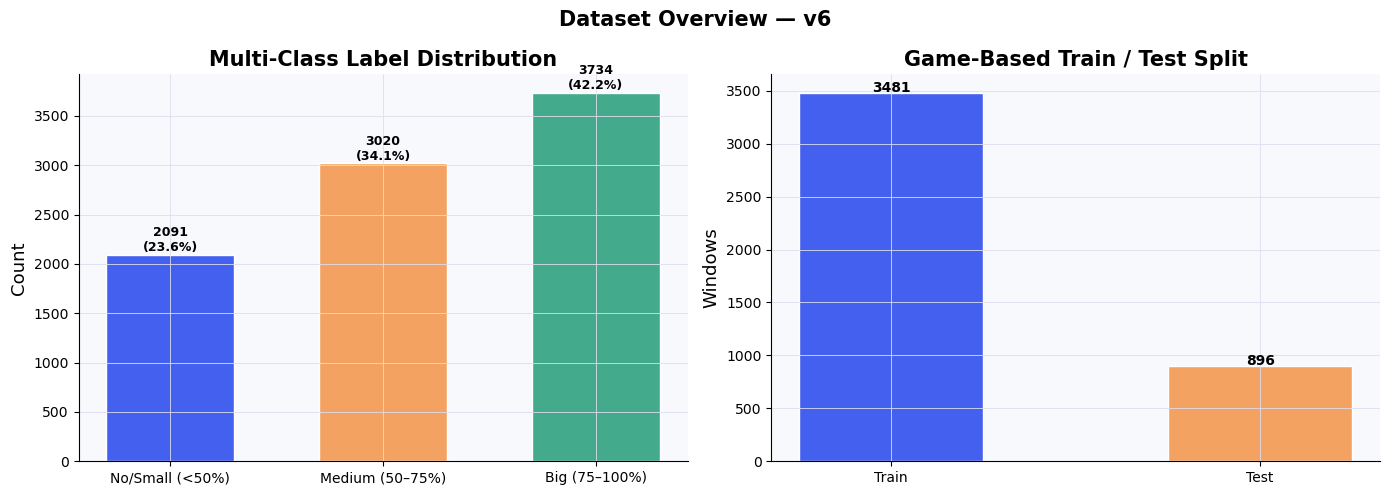


Feature correlations with label:
  avg_discount_depth_prev             +0.645  ###################
  max_discount_prev                   +0.637  ###################
  n_big_discounts_prev                +0.536  ################
  game_age_days                       +0.360  ##########
  avg_discount_frequency              +0.351  ##########
  n_itad_records                      +0.192  #####
  days_since_last_discount            -0.191  #####
  never_discounted                    -0.144  ####


In [88]:
# ── CELL 9: EDA ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dataset Overview — v6', fontsize=15, fontweight='bold')

colors = [BLUE, ORANGE, GREEN]
counts = [len(df[df[TARGET]==i]) for i in range(3)]
bars   = axes[0].bar(CLASS_NAMES, counts, color=colors, edgecolor='white', width=0.6)
axes[0].set_title('Multi-Class Label Distribution')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f'{val}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1].bar(['Train', 'Test'], [len(train_df), len(test_df)],
            color=[BLUE, ORANGE], edgecolor='white', width=0.5)
axes[1].set_title('Game-Based Train / Test Split')
axes[1].set_ylabel('Windows')
for i, val in enumerate([len(train_df), len(test_df)]):
    axes[1].text(i, val+10, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nFeature correlations with label:')
corr = df[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
for feat, val in corr.items():
    bar = '#' * int(abs(val) * 30)
    sign = '+' if val > 0 else '-'
    print(f'  {feat:<35} {sign}{abs(val):.3f}  {bar}')

In [90]:
# ── CELL 10: Model Training ───────────────────────────────────────
import time as time_module

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED,
                                               multi_class='multinomial'),
    'Random Forest':       RandomForestClassifier(
                               n_estimators=200,
                               max_depth=15,          # v7: prevent overfitting
                               min_samples_leaf=5,    # v7: prevent overfitting
                               random_state=SEED,
                               n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=SEED),
    'Naive Bayes':         GaussianNB(),
}

trained   = {}
fit_times = {}
results   = []

for name, model in models.items():
    t0 = time_module.time()
    model.fit(X_train_sc, y_train)
    fit_times[name] = time_module.time() - t0
    trained[name]   = model

    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)

    # For multi-class AUC: one-vs-rest
    try:
        auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
    except:
        auc = None

    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    acc  = (y_pred == y_test).mean()

    results.append({
        'Model':     name,
        'Accuracy':  round(acc,  4),
        'F1 (w)':   round(f1,   4),
        'Precision': round(prec, 4),
        'Recall':    round(rec,  4),
        'AUC (OvR)': round(auc, 4) if auc else None,
        'Time (s)':  round(fit_times[name], 3),
    })
    auc_str = f'{auc:.3f}' if auc else 'N/A'
    print(f'{name:<25} Acc={acc:.3f}  F1={f1:.3f}  AUC={auc_str}  t={fit_times[name]:.2f}s')

results_df = pd.DataFrame(results).set_index('Model')
display(results_df.style
    .background_gradient(subset=['F1 (w)', 'AUC (OvR)'], cmap='Blues')
    .highlight_max(subset=['F1 (w)', 'AUC (OvR)', 'Accuracy'], color='#bfdbfe')
    .set_caption('Multi-Class Results — Game-Based Test Split'))


Logistic Regression       Acc=0.797  F1=0.796  AUC=0.888  t=0.03s
Random Forest             Acc=0.823  F1=0.826  AUC=0.943  t=0.48s
Gradient Boosting         Acc=0.791  F1=0.798  AUC=0.913  t=2.20s
Naive Bayes               Acc=0.763  F1=0.764  AUC=0.865  t=0.00s


,Accuracy,F1 (w),Precision,Recall,AUC (OvR),Time (s)
Model,,,,,,
Logistic Regression,0.796900,0.795900,0.820700,0.796900,0.888000,0.027000
Random Forest,0.822500,0.826500,0.842000,0.822500,0.943400,0.476000
Gradient Boosting,0.791300,0.797900,0.821300,0.791300,0.913100,2.196000
Naive Bayes,0.763400,0.763900,0.767500,0.763400,0.864800,0.004000


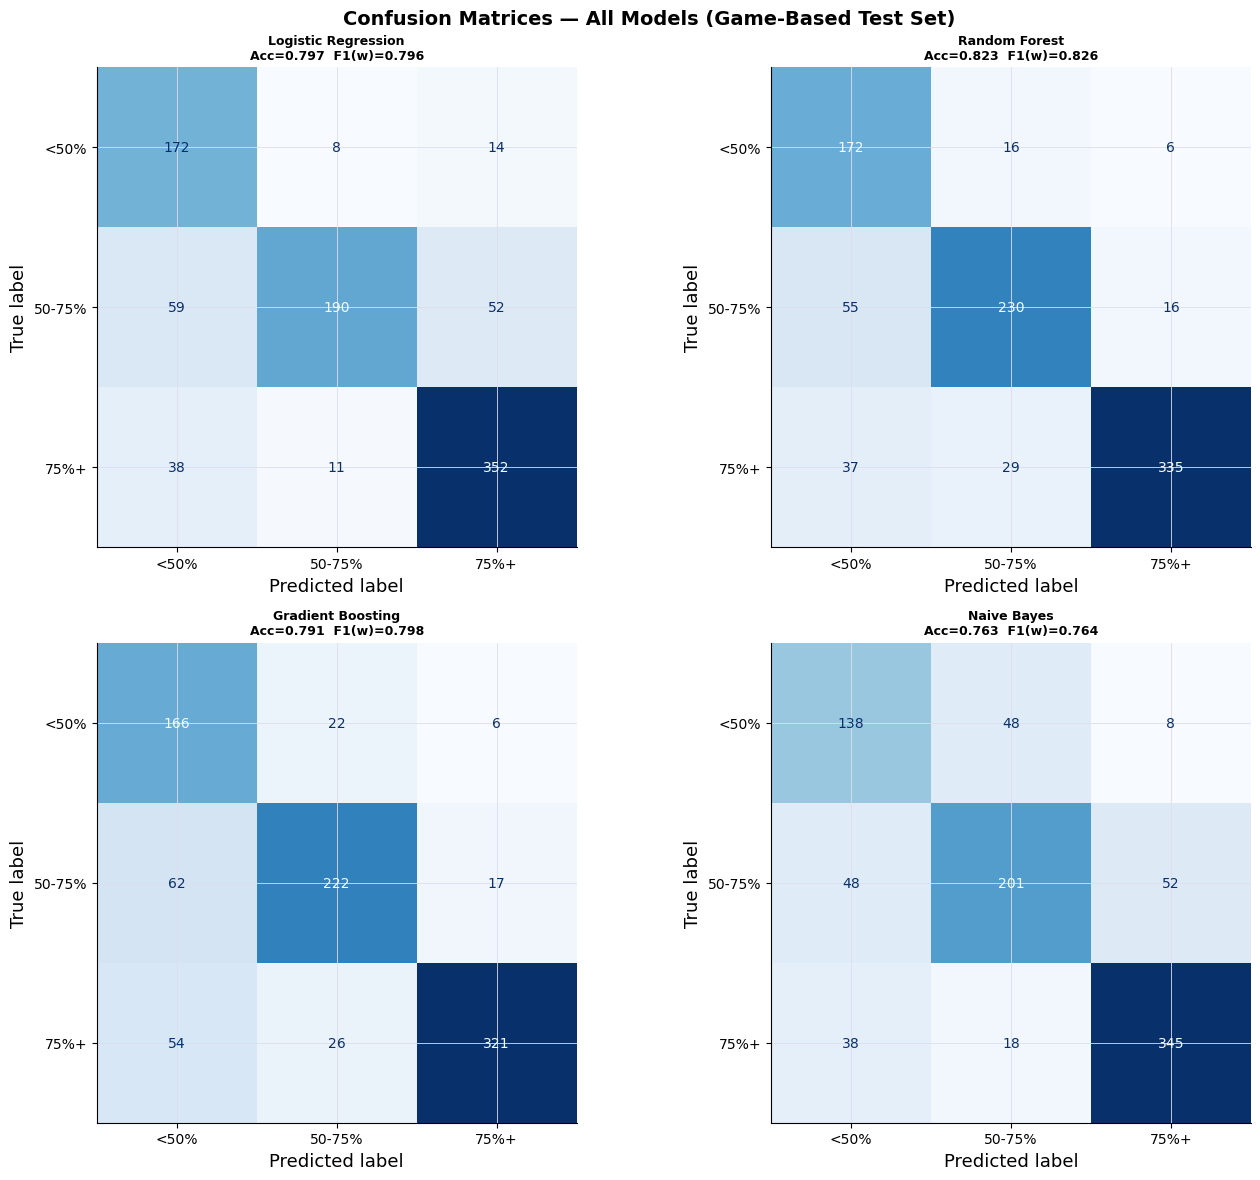

In [92]:
# ── CELL 11: Confusion Matrices ──────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Confusion Matrices — All Models (Game-Based Test Set)',
             fontsize=14, fontweight='bold')
for ax, (name, model) in zip(axes.flat, trained.items()):
    y_pred = model.predict(X_test_sc)
    cm     = confusion_matrix(y_test, y_pred, labels=[0,1,2])
    acc    = (y_pred == y_test).mean()
    f1     = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    disp   = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=['<50%','50-75%','75%+'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}\nAcc={acc:.3f}  F1(w)={f1:.3f}', fontsize=9, pad=6)
plt.tight_layout()
plt.show()

In [94]:
# ── CELL 12: Classification Reports ──────────────────────────────
best_name = results_df['F1 (w)'].idxmax()
print(f'Best model by weighted F1: {best_name}')
print('='*60)
best_model = trained[best_name]
y_pred = best_model.predict(X_test_sc)
print(classification_report(y_test, y_pred,
      target_names=CLASS_NAMES, zero_division=0))


Best model by weighted F1: Random Forest
                 precision    recall  f1-score   support

No/Small (<50%)       0.65      0.89      0.75       194
Medium (50–75%)       0.84      0.76      0.80       301
  Big (75–100%)       0.94      0.84      0.88       401

       accuracy                           0.82       896
      macro avg       0.81      0.83      0.81       896
   weighted avg       0.84      0.82      0.83       896



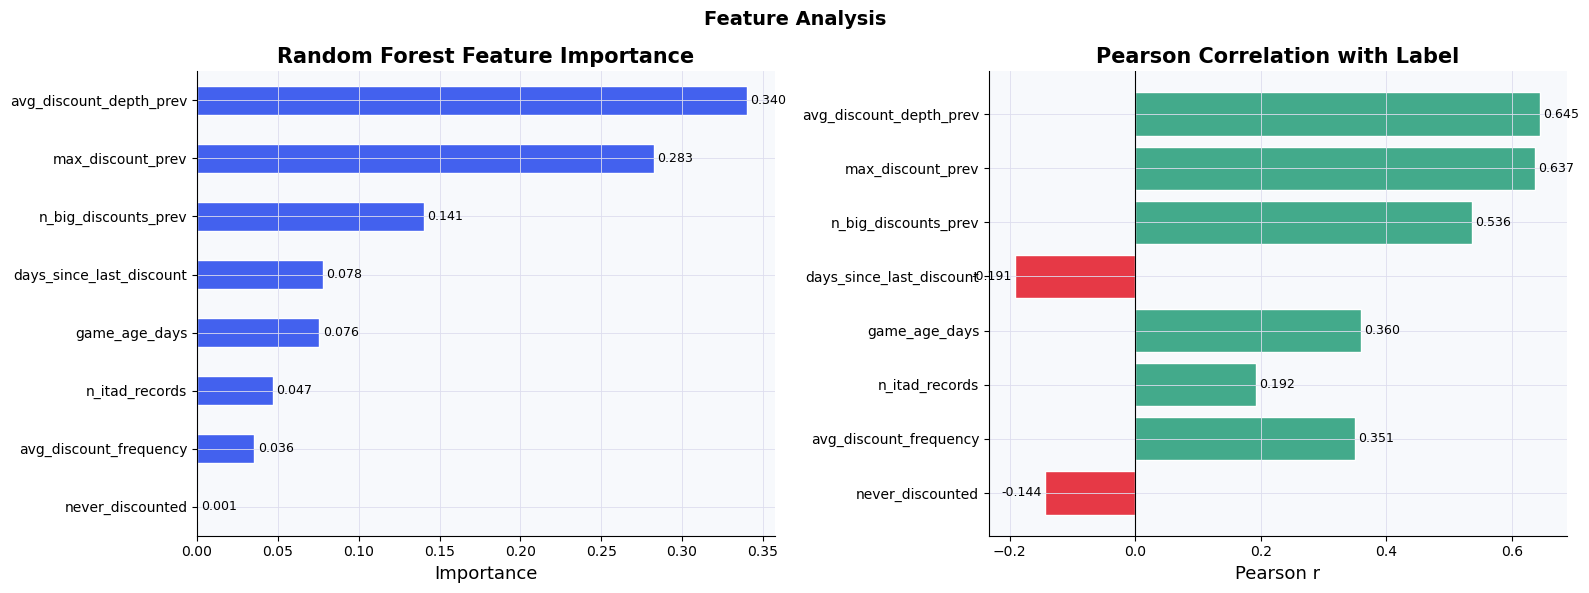

In [96]:
# ── CELL 13: Feature Importance ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Analysis', fontsize=14, fontweight='bold')

# Random Forest importance
rf = trained['Random Forest']
imp_vals = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
imp_vals.plot(kind='barh', ax=axes[0], color=BLUE, edgecolor='white')
axes[0].set_title('Random Forest Feature Importance')
axes[0].set_xlabel('Importance')
for i, val in enumerate(imp_vals):
    axes[0].text(val+0.002, i, f'{val:.3f}', va='center', fontsize=9)

# Correlation with label
corr_vals = df[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET)
corr_vals = corr_vals.reindex(imp_vals.index)
colors_c  = [GREEN if v > 0 else RED for v in corr_vals.values]
axes[1].barh(corr_vals.index, corr_vals.values, color=colors_c, edgecolor='white')
axes[1].set_title('Pearson Correlation with Label')
axes[1].set_xlabel('Pearson r')
axes[1].axvline(0, color='black', linewidth=0.8)
for i, val in enumerate(corr_vals.values):
    axes[1].text(val+0.005 if val >= 0 else val-0.005, i,
                 f'{val:.3f}', va='center', fontsize=9,
                 ha='left' if val >= 0 else 'right')

plt.tight_layout()
plt.show()


In [98]:
# ── CELL 14: Error Analysis ───────────────────────────────────────
best_model = trained[best_name]
y_pred = best_model.predict(X_test_sc)
y_prob = best_model.predict_proba(X_test_sc)

test_analysis = test_df.copy().reset_index(drop=True)
test_analysis['y_pred']      = y_pred
test_analysis['y_true']      = y_test
test_analysis['confidence']  = y_prob.max(axis=1)
test_analysis['correct']     = (y_pred == y_test)

print(f'=== MODEL: {best_name} ===')
print(f'Overall accuracy: {test_analysis["correct"].mean():.3f}')
print()

# Errors per class
for true_cls in range(3):
    subset = test_analysis[test_analysis['y_true'] == true_cls]
    errors = subset[~subset['correct']]
    if len(errors) > 0:
        print(f'--- True class {true_cls} ({CLASS_NAMES[true_cls]}) ---')
        print(f'  Total: {len(subset)}  |  Errors: {len(errors)}  ({len(errors)/len(subset)*100:.1f}%)')
        print(f'  Predicted as: {errors["y_pred"].value_counts().to_dict()}')
        print()

# Most confidently wrong predictions
wrong = test_analysis[~test_analysis['correct']].nlargest(10, 'confidence')
print('\n=== Top 10 Most Confidently Wrong ===')
print(wrong[['game_name','y_true','y_pred','confidence',
             'days_since_last_discount','avg_discount_frequency']].to_string())


=== MODEL: Random Forest ===
Overall accuracy: 0.823

--- True class 0 (No/Small (<50%)) ---
  Total: 194  |  Errors: 22  (11.3%)
  Predicted as: {1: 16, 2: 6}

--- True class 1 (Medium (50–75%)) ---
  Total: 301  |  Errors: 71  (23.6%)
  Predicted as: {0: 55, 2: 16}

--- True class 2 (Big (75–100%)) ---
  Total: 401  |  Errors: 66  (16.5%)
  Predicted as: {0: 37, 1: 29}


=== Top 10 Most Confidently Wrong ===
                                             game_name  y_true  y_pred  confidence  days_since_last_discount  avg_discount_frequency
440  NARUTO SHIPPUDEN: Ultimate Ninja STORM Revolution       1       2    0.999253                 18.236516                    1.00
706                       NARUTO: Ultimate Ninja STORM       1       2    0.986558                 18.236516                    1.00
796                                          Autonauts       0       2    0.984329                 24.237106                    1.00
426                                             PixARK

In [100]:
# ── CELL 15: Save All Models ──────────────────────────────────────
import joblib

# Tüm modelleri ayrı ayrı kaydet
for name, model in trained.items():
    fname = f"model_v7_{name.lower().replace(' ', '_')}.joblib"
    joblib.dump(model, fname)
    print(f"Saved: {fname}")

model_meta = {
    'best_model_name': best_name,
    'features':        FEATURES,
    'class_names':     CLASS_NAMES,
    'window_days':     WINDOW_DAYS,
    'model_names':     list(trained.keys()),
    'version':         'v7',
}
with open('model_meta_v7.json', 'w') as f:
    json.dump(model_meta, f, indent=2)

print(f'\nBest model: {best_name}')
print(f'Saved: model_meta_v7.json')

Saved: model_v7_logistic_regression.joblib
Saved: model_v7_random_forest.joblib
Saved: model_v7_gradient_boosting.joblib
Saved: model_v7_naive_bayes.joblib

Best model: Random Forest
Saved: model_meta_v7.json


In [102]:
# ── CELL 16: Live Prediction Function ────────────────────────────
# This function takes any game name, queries ITAD live, and predicts.

def get_itad_id_by_name(game_name):
    """Search ITAD for a game by name and return its ID."""
    url = f'https://api.isthereanydeal.com/games/search/v1?key={ITAD_KEY}&title={requests.utils.quote(game_name)}&results=5'
    try:
        r = requests.get(url, timeout=10)
        results = r.json()
        if results:
            return results[0].get('id'), results[0].get('title')
        return None, None
    except:
        return None, None

def get_steam_appid_by_name(game_name):
    """Search Steam Store for appid by name."""
    url = f'https://store.steampowered.com/api/storesearch/?term={requests.utils.quote(game_name)}&l=en&cc=us'
    try:
        r = requests.get(url, timeout=10)
        items = r.json().get('items', [])
        if items:
            return items[0]['id'], items[0]['name']
        return None, None
    except:
        return None, None

def compute_live_features(appid, game_name, base_price_usd, release_date_str):
    """Compute features from live ITAD data for a single game."""
    itad_id = get_itad_id(appid)
    if not itad_id:
        return None, 'Could not find game on ITAD'

    history_raw = get_itad_history(itad_id)
    if len(history_raw) < 2:
        return None, 'Insufficient price history on ITAD'

    history    = parse_history(history_raw)
    now_ts     = int(datetime.now().timestamp())
    step       = WINDOW_DAYS * 86400
    release_dt = parse_release_date(release_date_str)

    game_age_days = (datetime.now() - release_dt).days if release_dt else None

    past_disc_ts = [ts for ts, _, c in history if ts < now_ts and c >= 10]
    days_since_last_discount = (now_ts - max(past_disc_ts)) / 86400 if past_disc_ts else 730

    prev_start   = now_ts - step
    prev_records = [(ts, p, c) for ts, p, c in history if prev_start <= ts < now_ts]
    n_itad_records = len(prev_records) if prev_records else 0

    prev_cuts = [c for _, _, c in prev_records]
    max_discount_prev       = max(prev_cuts) if prev_cuts else 0
    sig_cuts                = [c for c in prev_cuts if c >= 10]
    avg_discount_depth_prev = np.mean(sig_cuts) if sig_cuts else 0
    n_big_discounts_prev    = sum(1 for c in prev_cuts if c >= 50)

    # v7: never_discounted flag
    never_discounted_flag = 0 if past_disc_ts else 1

    pre_year_start = now_ts - 365 * 86400
    freq_windows   = []
    pt = pre_year_start
    while pt + step <= now_ts:
        pw_cuts = [c for ts, _, c in history if pt <= ts < pt + step and c >= 10]
        freq_windows.append(1 if pw_cuts else 0)
        pt += step
    avg_discount_frequency = np.mean(freq_windows) if freq_windows else 0

    features = {
        'game_age_days':            game_age_days,
        'days_since_last_discount': days_since_last_discount,
        'n_itad_records':           n_itad_records,
        'max_discount_prev':        max_discount_prev,
        'avg_discount_depth_prev':  avg_discount_depth_prev,
        'n_big_discounts_prev':     n_big_discounts_prev,
        'avg_discount_frequency':   avg_discount_frequency,
        'never_discounted':          never_discounted_flag,  # v7
    }
    return features, None

def predict_for_game(game_name_query):
    """
    Full pipeline: search → fetch → compute features → predict.
    Returns prediction and feature values.
    """
    # 1. Search Steam
    appid, found_name = get_steam_appid_by_name(game_name_query)
    if not appid:
        return {'error': f'Game not found on Steam: {game_name_query}'}

    print(f'Found: {found_name} (appid: {appid})')

    # 2. Get Steam details
    details = get_steam_details(appid)
    if not details:
        return {'error': 'Could not get Steam details (free-to-play or no price)'}

    # 3. Compute features
    features, err = compute_live_features(
        appid, found_name,
        details['base_price_usd'],
        details['release_date']
    )
    if err:
        return {'error': err}

    # 4. Impute + scale + predict
    X = pd.DataFrame([features], columns=FEATURES)
    X_imp = pd.DataFrame(imp.transform(X), columns=FEATURES)
    X_sc  = pd.DataFrame(scaler.transform(X_imp), columns=FEATURES)

    pred_class = int(trained[best_name].predict(X_sc)[0])
    proba      = trained[best_name].predict_proba(X_sc)[0]

    # TRY pricing
    USD_TRY     = 43.90
    steam_try   = details['base_price_usd'] * 0.50 * USD_TRY
    epic_try    = steam_try * 0.85

    return {
        'game_name':    found_name,
        'appid':        appid,
        'prediction':   pred_class,
        'class_name':   CLASS_NAMES[pred_class],
        'probabilities': {CLASS_NAMES[i]: round(float(p), 3) for i, p in enumerate(proba)},
        'confidence':   round(float(max(proba)), 3),
        'features':     {k: round(v, 2) if v is not None else None for k, v in features.items()},
        'steam_now_try': round(steam_try, 2),
        'epic_try':      round(epic_try, 2),
        'window_days':   WINDOW_DAYS,
    }

print('Live prediction function ready.')
print('Usage: result = predict_for_game("Elden Ring")')
print('result')


Live prediction function ready.
Usage: result = predict_for_game("Elden Ring")
result


In [108]:
# ── CELL 17: Test Live Prediction ────────────────────────────────
# Test with a few games
test_games_live = ['Left 4 Dead 2', 'Elden Ring', 'Stardew Valley']

for game in test_games_live:
    print(f'\n{'='*50}')
    print(f'Querying: {game}')
    result = predict_for_game(game)
    if 'error' in result:
        print(f'ERROR: {result["error"]}')
    else:
        print(f'Game      : {result["game_name"]}')
        print(f'Prediction: {result["class_name"]}  (confidence: {result["confidence"]:.1%})')
        print(f'Probabilities:')
        for cls, prob in result['probabilities'].items():
            print(f'  {cls:<25} {prob:.3f}')
        print(f'Steam now : ₺{result["steam_now_try"]:,.0f}')
        print(f'Epic now  : ₺{result["epic_try"]:,.0f}')
        print(f'Features  : {result["features"]}')
    time.sleep(1)



Querying: Left 4 Dead 2
Found: Left 4 Dead 2 (appid: 550)
Game      : Left 4 Dead 2
Prediction: No/Small (<50%)  (confidence: 61.2%)
Probabilities:
  No/Small (<50%)           0.612
  Medium (50–75%)           0.143
  Big (75–100%)             0.246
Steam now : ₺219
Epic now  : ₺186
Features  : {'game_age_days': 6061, 'days_since_last_discount': 93.92, 'n_itad_records': 1, 'max_discount_prev': 0.0, 'avg_discount_depth_prev': 0, 'n_big_discounts_prev': 0, 'avg_discount_frequency': 1.0, 'never_discounted': 0}

Querying: Elden Ring
Found: ELDEN RING (appid: 1245620)
Game      : ELDEN RING
Prediction: No/Small (<50%)  (confidence: 65.0%)
Probabilities:
  No/Small (<50%)           0.650
  Medium (50–75%)           0.181
  Big (75–100%)             0.169
Steam now : ₺1,317
Epic now  : ₺1,119
Features  : {'game_age_days': 1578, 'days_since_last_discount': 93.95, 'n_itad_records': 1, 'max_discount_prev': 0.0, 'avg_discount_depth_prev': 0, 'n_big_discounts_prev': 0, 'avg_discount_frequency': 0

In [110]:
# ── LIVE DEMO  ────────────────────────────────
result = predict_for_game("Cyberpunk 2077")
if 'error' not in result:
    print(f"Game      : {result['game_name']}")
    print(f"Prediction    : {result['class_name']}")
    print(f"Confidence     : {result['confidence']:.1%}")
    print(f"Steam TRY : ₺{result['steam_now_try']:,.0f}")
    print(f"Epic TRY  : ₺{result['epic_try']:,.0f}")
    print(f"Probabilities:")
    for cls, prob in result['probabilities'].items():
        print(f"  {cls}: {prob:.1%}")

Found: Cyberpunk 2077 (appid: 1091500)
Game      : Cyberpunk 2077
Prediction    : Medium (50–75%)
Confidence     : 82.5%
Steam TRY : ₺1,317
Epic TRY  : ₺1,119
Probabilities:
  No/Small (<50%): 4.1%
  Medium (50–75%): 82.5%
  Big (75–100%): 13.4%


In [112]:
# ── CELL 17b: Save Recommendations (full dataset) ────────────────
USD_TRY = 43.90

# Tüm dataset — winsorization train bounds ile uygula (v7 fix)
all_games_df = df.copy()
cap_cols_fix = ['game_age_days', 'days_since_last_discount']
for col in cap_cols_fix:
    Q1, Q3 = train_df[col].quantile(0.25), train_df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    all_games_df[col] = all_games_df[col].clip(lower=lo, upper=hi)

X_all = pd.DataFrame(
    scaler.transform(imp.transform(all_games_df[FEATURES])),
    columns=FEATURES, index=all_games_df.index)

best_model   = trained[best_name]
y_pred_all   = best_model.predict(X_all)
y_prob_all   = best_model.predict_proba(X_all)

recs = []
for i, (_, row) in enumerate(all_games_df.reset_index(drop=True).iterrows()):
    steam_try = row.get('base_price', 20.0) * 0.50 * USD_TRY
    epic_try  = steam_try * 0.85
    recs.append({
        'appid':                    int(row['appid']),
        'game_name':                str(row['game_name']),
        'prediction':               int(y_pred_all[i]),
        'class_name':               CLASS_NAMES[int(y_pred_all[i])],
        'confidence':               round(float(max(y_prob_all[i])), 3),
        'steam_now_try':            round(steam_try, 2),
        'epic_try':                 round(epic_try, 2),
        'game_age_days':            row['game_age_days'],
        'days_since_last_discount': row['days_since_last_discount'],
        'avg_discount_frequency':   row['avg_discount_frequency'],
        'max_discount_prev':        row['max_discount_prev'],
        'never_discounted':         int(row.get('never_discounted', 0)),
    })

recs_df = pd.DataFrame(recs)
# Deduplicate — her oyun için en yüksek confidence'lı pencereyi tut
recs_df = recs_df.sort_values('confidence', ascending=False).drop_duplicates(subset=['appid'])
recs_df.to_csv('steam_recommendations_v6.csv', index=False)
print(f"Saved {len(recs_df)} recommendations ({recs_df['appid'].nunique()} unique games)")
print(recs_df['class_name'].value_counts())

Saved 2269 recommendations (2269 unique games)
class_name
Big (75–100%)      990
Medium (50–75%)    751
No/Small (<50%)    528
Name: count, dtype: int64


In [114]:
from sklearn.metrics import accuracy_score
for name, model in trained.items():
    train_acc = accuracy_score(y_train, model.predict(X_train_sc))
    test_acc  = accuracy_score(y_test,  model.predict(X_test_sc))
    gap = train_acc - test_acc
    print(f"{name:<25} Train={train_acc:.3f}  Test={test_acc:.3f}  Gap={gap:+.3f}")

Logistic Regression       Train=0.791  Test=0.797  Gap=-0.006
Random Forest             Train=0.877  Test=0.823  Gap=+0.055
Gradient Boosting         Train=0.904  Test=0.791  Gap=+0.113
Naive Bayes               Train=0.769  Test=0.763  Gap=+0.006


In [116]:
# ── CELL 18: 30-Day Window Comparison ────────────────────────────
import copy
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

print("Building 30-day windows from existing raw data...")

WINDOW_DAYS_30 = 30
rows_30 = []
skipped_30 = 0

for _, row in df_raw.iterrows():
    try:
        history = parse_history(json.loads(row['price_history']))
        if len(history) < 3:
            skipped_30 += 1; continue

        release_dt = parse_release_date(row['release_date'])
        end_ts_30  = DATASET_END_TS
        start_ts_30 = end_ts_30 - 365 * 86400
        step_30 = WINDOW_DAYS_30 * 86400
        t = start_ts_30

        while t + step_30 <= end_ts_30:
            w_start = t
            w_end   = t + step_30

            future_cuts = [c for ts, _, c in history if w_start <= ts < w_end]
            max_cut     = max(future_cuts) if future_cuts else 0
            label       = get_discount_label(max_cut)

            q_start_dt = datetime.fromtimestamp(w_start)
            if release_dt:
                game_age_days = (q_start_dt - release_dt).days
                if game_age_days < 0:
                    t += step_30; continue
            else:
                game_age_days = None

            past_disc_ts = [ts for ts, _, c in history if ts < w_start and c >= 10]
            days_since = (w_start - max(past_disc_ts)) / 86400 if past_disc_ts else 730

            prev_start   = w_start - step_30
            prev_records = [(ts, p, c) for ts, p, c in history if prev_start <= ts < w_start]
            n_itad = len(prev_records) if prev_records else None
            prev_cuts = [c for _, _, c in prev_records]
            max_disc_prev = max(prev_cuts) if prev_cuts else 0
            sig_cuts = [c for c in prev_cuts if c >= 10]
            avg_depth = np.mean(sig_cuts) if sig_cuts else 0
            n_big = sum(1 for c in prev_cuts if c >= 50)
            never_discounted = 0 if [ts for ts, _, c in history if ts < w_start and c >= 10] else 1

            pre_year = w_start - 365 * 86400
            freq_wins = []
            pt = pre_year
            while pt + step_30 <= w_start:
                pw = [c for ts, _, c in history if pt <= ts < pt + step_30 and c >= 10]
                freq_wins.append(1 if pw else 0)
                pt += step_30
            avg_freq = np.mean(freq_wins) if freq_wins else np.nan

            rows_30.append({
                'appid': row['appid'], 'window_start_ts': w_start,
                'game_age_days': game_age_days,
                'days_since_last_discount': days_since,
                'n_itad_records': n_itad,
                'max_discount_prev': max_disc_prev,
                'avg_discount_depth_prev': avg_depth,
                'n_big_discounts_prev': n_big,
                'never_discounted': never_discounted,
                'avg_discount_frequency': avg_freq,
                'label': label,
            })
            t += step_30
    except:
        skipped_30 += 1

df30 = pd.DataFrame(rows_30)
print(f"30-day windows: {len(df30):,} | Unique games: {df30['appid'].nunique():,}")
print(f"Class distribution:")
vc30 = df30['label'].value_counts().sort_index()
names = {0:'<50%', 1:'50-75%', 2:'>=75%'}
for cls, cnt in vc30.items():
    print(f"  Class {cls} ({names[cls]}): {cnt} ({cnt/len(df30)*100:.1f}%)")

Building 30-day windows from existing raw data...
30-day windows: 26,713 | Unique games: 2,289
Class distribution:
  Class 0 (<50%): 13464 (50.4%)
  Class 1 (50-75%): 6081 (22.8%)
  Class 2 (>=75%): 7168 (26.8%)


In [118]:
# ── CELL 19: 30-Day Window — Model Training & Comparison ──────────

# Combined split for 30-day windows — same temporal logic as 90-day
all_games_30 = df30['appid'].unique()
np.random.seed(SEED)
np.random.shuffle(all_games_30)
split_30   = int(len(all_games_30) * 0.80)
train_g30  = set(all_games_30[:split_30])
test_g30   = set(all_games_30[split_30:])

cutoff_30 = df30.sort_values('window_start_ts')['window_start_ts'].quantile(0.50)

train_30 = df30[
    df30['appid'].isin(train_g30) &
    (df30['window_start_ts'] < cutoff_30)
].copy()

test_30 = df30[
    df30['appid'].isin(test_g30) &
    (df30['window_start_ts'] >= cutoff_30)
].copy()

print(f"30-day temporal cutoff: {pd.Timestamp(cutoff_30, unit='s').strftime('%Y-%m-%d')}")

print(f"Train: {len(train_30):,} windows | Test: {len(test_30):,} windows")
print(f"Game overlap: {len(set(train_30['appid']) & set(test_30['appid']))}")
print(f"\nClass distribution (test):")
for i, c in test_30['label'].value_counts().sort_index().items():
    print(f"  Class {i}: {c} ({c/len(test_30)*100:.1f}%)")

# Winsorization — train only
for col in ['game_age_days','days_since_last_discount']:
    Q1, Q3 = train_30[col].quantile(0.25), train_30[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    train_30[col] = train_30[col].clip(lo, hi)
    test_30[col]  = test_30[col].clip(lo, hi)

# Imputation + scaling
imp30 = SimpleImputer(strategy='median')
sc30  = StandardScaler()
X_tr30 = sc30.fit_transform(imp30.fit_transform(train_30[FEATURES]))
X_te30 = sc30.transform(imp30.transform(test_30[FEATURES]))
y_tr30 = train_30['label'].values
y_te30 = test_30['label'].values

# Models with class_weight='balanced' for imbalanced classes
models_30 = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED,
                                               multi_class='multinomial',
                                               class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=SEED,
                                                   n_jobs=-1, class_weight='balanced'),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=SEED),
    'Naive Bayes':         GaussianNB(),
}

print(f"\n{'Model':<25} {'F1 (w)':>8} {'AUC (OvR)':>10}")
print("-" * 46)
results_30 = []
for name, model in models_30.items():
    model.fit(X_tr30, y_tr30)
    y_pred = model.predict(X_te30)
    y_prob = model.predict_proba(X_te30)
    f1  = f1_score(y_te30, y_pred, average='weighted', zero_division=0)
    try:
        auc = roc_auc_score(y_te30, y_prob, multi_class='ovr', average='weighted')
    except:
        auc = None
    results_30.append({'Model': name, 'F1 (w)': round(f1,3),
                        'AUC (OvR)': round(auc,3) if auc else None})
    print(f"  {name:<23} {f1:8.3f} {auc:10.3f}")

# Comparison table
print("\n=== 90-day vs 30-day Comparison (game-based split) ===")
print(f"{'Model':<25} {'90d F1':>8} {'90d AUC':>9} {'30d F1':>8} {'30d AUC':>9}")
print("-" * 62)
for name, r30 in zip(results_df.index.tolist(), results_30):
    f1_90  = results_df.loc[name, 'F1 (w)']
    auc_90 = results_df.loc[name, 'AUC (OvR)']
    print(f"  {name:<23} {f1_90:8.3f} {auc_90:9.3f} {r30['F1 (w)']:8.3f} {r30['AUC (OvR)']:9.3f}")

30-day temporal cutoff: 2024-10-02
Train: 10,471 windows | Test: 2,719 windows
Game overlap: 0

Class distribution (test):
  Class 0: 1180 (43.4%)
  Class 1: 709 (26.1%)
  Class 2: 830 (30.5%)

Model                       F1 (w)  AUC (OvR)
----------------------------------------------
  Logistic Regression        0.536      0.709
  Random Forest              0.482      0.724
  Gradient Boosting          0.476      0.705
  Naive Bayes                0.510      0.702

=== 90-day vs 30-day Comparison (game-based split) ===
Model                       90d F1   90d AUC   30d F1   30d AUC
--------------------------------------------------------------
  Logistic Regression        0.796     0.888    0.536     0.709
  Random Forest              0.827     0.943    0.482     0.724
  Gradient Boosting          0.798     0.913    0.476     0.705
  Naive Bayes                0.764     0.865    0.510     0.702


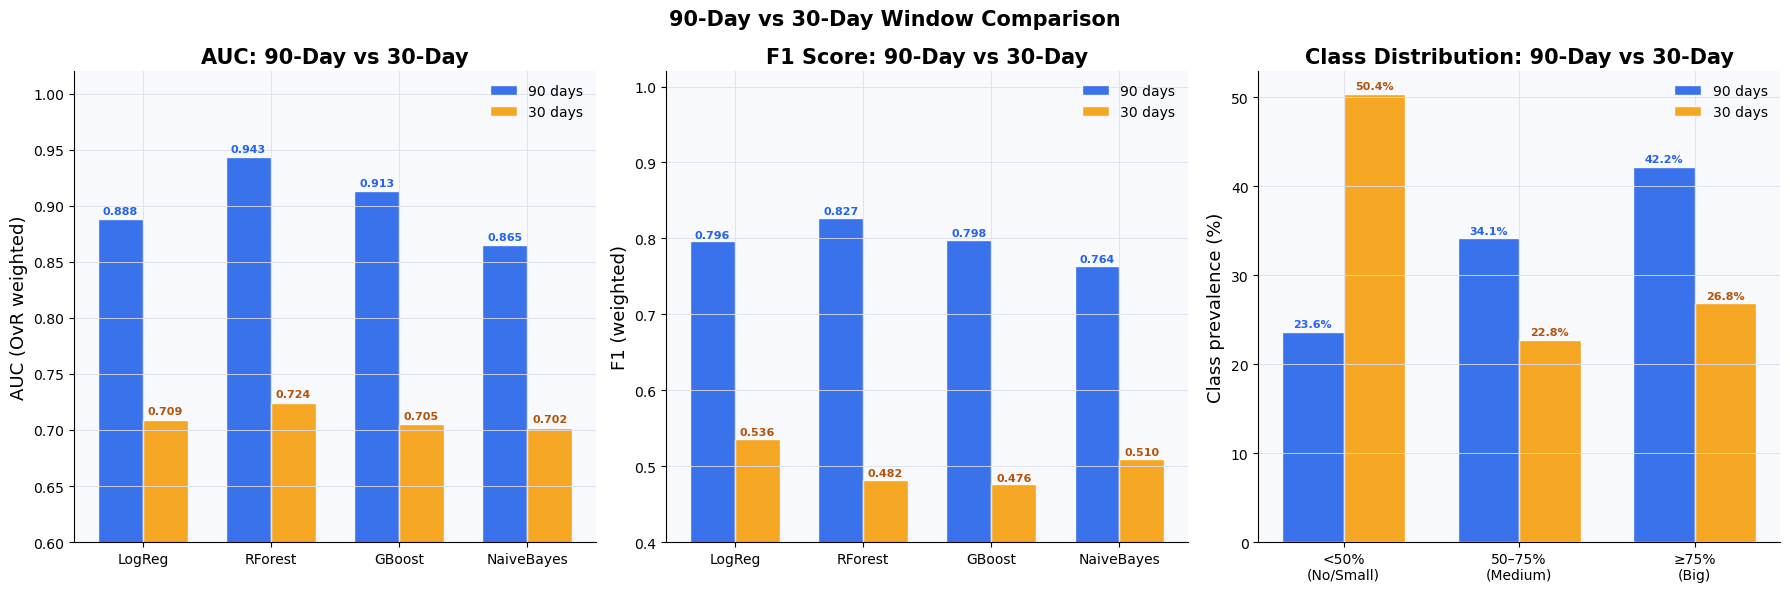

Key takeaway:
  90-day → Best AUC: 0.943  |  Class 0: 23.6%
  30-day → Best AUC: 0.724  |  Class 0: 50.4%

  30-day Class 0 oranı 26.8 puan daha yüksek
  90-day AUC 0.219 daha yüksek


In [120]:
# ── CELL 20: 90-Day vs 30-Day Visual Comparison ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("90-Day vs 30-Day Window Comparison",
             fontsize=15, fontweight="bold")

models_names_short = ["LogReg", "RForest", "GBoost", "NaiveBayes"]
auc_90 = results_df["AUC (OvR)"].values.astype(float)
f1_90  = results_df["F1 (w)"].values.astype(float)
auc_30 = [r["AUC (OvR)"] for r in results_30]
f1_30  = [r["F1 (w)"]    for r in results_30]

x     = np.arange(len(models_names_short))
width = 0.35
pal90 = "#2563eb"
pal30 = "#f59e0b"

# ── AUC comparison ────────────────────────────────────────────────
axes[0].bar(x - width/2, auc_90, width, label="90 days", color=pal90, edgecolor="white", alpha=0.9)
axes[0].bar(x + width/2, auc_30, width, label="30 days", color=pal30, edgecolor="white", alpha=0.9)
axes[0].set_xticks(x); axes[0].set_xticklabels(models_names_short, fontsize=10)
axes[0].set_ylim(0.60, 1.02)
axes[0].set_ylabel("AUC (OvR weighted)")
axes[0].set_title("AUC: 90-Day vs 30-Day")
axes[0].legend(fontsize=10)
for i in range(len(x)):
    axes[0].text(i - width/2, auc_90[i] + 0.005, f"{auc_90[i]:.3f}", ha="center", fontsize=8, color=pal90, fontweight="bold")
    axes[0].text(i + width/2, auc_30[i] + 0.005, f"{auc_30[i]:.3f}", ha="center", fontsize=8, color="#b45309", fontweight="bold")

# ── F1 comparison ─────────────────────────────────────────────────
axes[1].bar(x - width/2, f1_90, width, label="90 days", color=pal90, edgecolor="white", alpha=0.9)
axes[1].bar(x + width/2, f1_30, width, label="30 days", color=pal30, edgecolor="white", alpha=0.9)
axes[1].set_xticks(x); axes[1].set_xticklabels(models_names_short, fontsize=10)
axes[1].set_ylim(0.40, 1.02)
axes[1].set_ylabel("F1 (weighted)")
axes[1].set_title("F1 Score: 90-Day vs 30-Day")
axes[1].legend(fontsize=10)
for i in range(len(x)):
    axes[1].text(i - width/2, f1_90[i] + 0.005, f"{f1_90[i]:.3f}", ha="center", fontsize=8, color=pal90, fontweight="bold")
    axes[1].text(i + width/2, f1_30[i] + 0.005, f"{f1_30[i]:.3f}", ha="center", fontsize=8, color="#b45309", fontweight="bold")

# ── Class distribution comparison ────────────────────────────────
class_labels = ["<50%\n(No/Small)", "50–75%\n(Medium)", "≥75%\n(Big)"]
dist_90 = [
    len(df[df["label"]==0])/len(df)*100,
    len(df[df["label"]==1])/len(df)*100,
    len(df[df["label"]==2])/len(df)*100,
]
vc30 = df30["label"].value_counts().sort_index()
dist_30 = [vc30.get(i, 0)/len(df30)*100 for i in range(3)]

x2 = np.arange(3)
axes[2].bar(x2 - width/2, dist_90, width, label="90 days", color=pal90, edgecolor="white", alpha=0.9)
axes[2].bar(x2 + width/2, dist_30, width, label="30 days", color=pal30, edgecolor="white", alpha=0.9)
axes[2].set_xticks(x2); axes[2].set_xticklabels(class_labels, fontsize=10)
axes[2].set_ylabel("Class prevalence (%)")
axes[2].set_title("Class Distribution: 90-Day vs 30-Day")
axes[2].legend(fontsize=10)
for i in range(3):
    axes[2].text(i - width/2, dist_90[i] + 0.5, f"{dist_90[i]:.1f}%", ha="center", fontsize=8, color=pal90, fontweight="bold")
    axes[2].text(i + width/2, dist_30[i] + 0.5, f"{dist_30[i]:.1f}%", ha="center", fontsize=8, color="#b45309", fontweight="bold")

plt.tight_layout()
plt.show()

print("Key takeaway:")
print(f"  90-day → Best AUC: {max(auc_90):.3f}  |  Class 0: {dist_90[0]:.1f}%")
print(f"  30-day → Best AUC: {max(auc_30):.3f}  |  Class 0: {dist_30[0]:.1f}%")
print(f"\n  30-day Class 0 oranı {dist_30[0]-dist_90[0]:.1f} puan daha yüksek")
print(f"  90-day AUC {max(auc_90)-max(auc_30):.3f} daha yüksek")

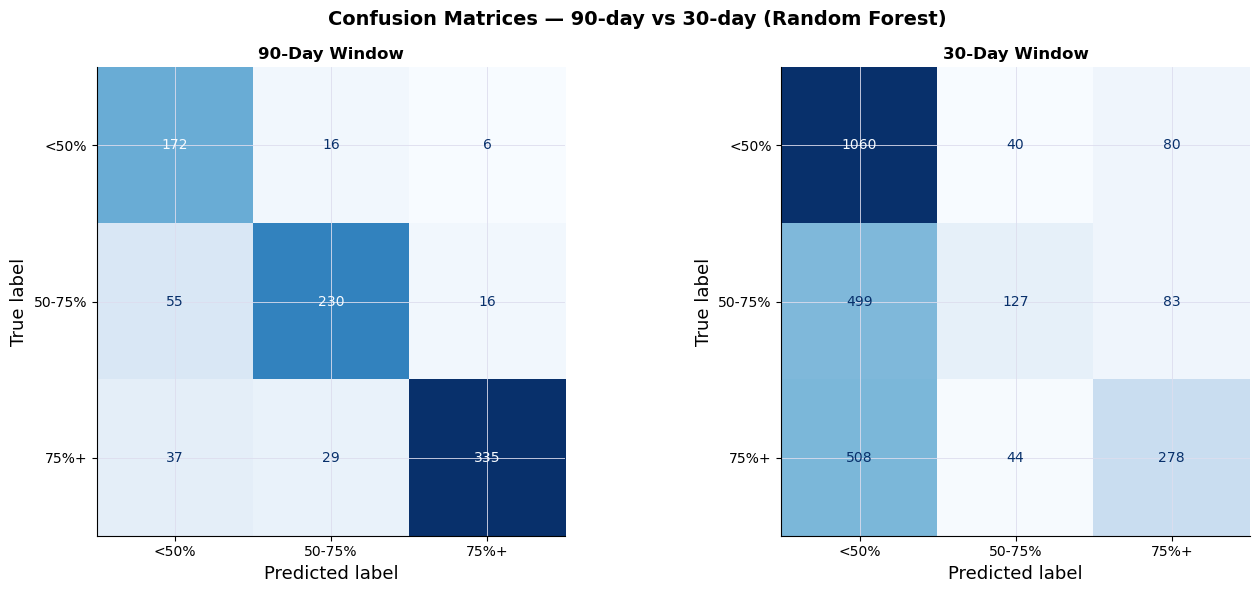

Q1 — Most Confused Class

90-day:
  Class <50%: 22 errors / 194 total (11.3%)
  Class 50-75%: 71 errors / 301 total (23.6%)
  Class 75%+: 66 errors / 401 total (16.5%)
  Medium→<50%: 55  |  Medium→75%+: 16

30-day:
  Class <50%: 120 errors / 1180 total (10.2%)
  Class 50-75%: 582 errors / 709 total (82.1%)
  Class 75%+: 552 errors / 830 total (66.5%)
  Medium→<50%: 499  |  Medium→75%+: 83

Q2 — Costly Error Rate (actual=Big, predicted=No/Small)

90-day: 37 costly errors / 401 actual Big windows = 9.2%
  never_discounted=1: 2 / 37
  days_since_last_discount mean: 117.8
  avg_discount_frequency mean:   0.68
  max_discount_prev mean:        0.5
  Sample games: ['Counter-Strike: Condition Zero', 'Portal 2', 'Layers of Fear (2016)', 'The Darkness II', 'Medal of Honor™']

30-day: 508 costly errors / 830 actual Big windows = 61.2%
  never_discounted=1: 2 / 508
  days_since_last_discount mean: 21.4
  avg_discount_frequency mean:   0.55
  max_discount_prev mean:        60.1

Q3 — 90-day vs 30-d

In [122]:
# ── CELL: Error Analysis — 90-day vs 30-day ──────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 90-day best model predictions
y_pred_90 = trained[best_name].predict(X_test_sc)
cm_90 = confusion_matrix(y_test, y_pred_90, labels=[0,1,2])

# 30-day best model predictions  
best_30 = 'Random Forest'
models_30_fitted = {}
imp30 = SimpleImputer(strategy='median')
sc30  = StandardScaler()
X_tr30_fit = sc30.fit_transform(imp30.fit_transform(train_30[FEATURES]))
X_te30_fit = sc30.transform(imp30.transform(test_30[FEATURES]))
y_te30 = test_30['label'].values

from sklearn.ensemble import RandomForestClassifier
rf30 = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=5, random_state=SEED, n_jobs=-1)
rf30.fit(X_tr30_fit, train_30['label'].values)
y_pred_30 = rf30.predict(X_te30_fit)
cm_30 = confusion_matrix(y_te30, y_pred_30, labels=[0,1,2])

# ── Confusion Matrices ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Confusion Matrices — 90-day vs 30-day (Random Forest)", fontsize=14, fontweight="bold")

for ax, cm, title in zip(axes, [cm_90, cm_30], ["90-Day Window", "30-Day Window"]):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<50%','50-75%','75%+'])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

# ── Q1: En çok karıştırılan sınıf ────────────────────────────────
print("=" * 60)
print("Q1 — Most Confused Class")
print("=" * 60)
for cm, label in [(cm_90, "90-day"), (cm_30, "30-day")]:
    total = cm.sum()
    print(f"\n{label}:")
    for i, cls in enumerate(['<50%','50-75%','75%+']):
        errors = cm[i].sum() - cm[i][i]
        print(f"  Class {cls}: {errors} errors / {cm[i].sum()} total ({errors/cm[i].sum()*100:.1f}%)")
    # Medium confusion breakdown
    print(f"  Medium→<50%: {cm[1][0]}  |  Medium→75%+: {cm[1][2]}")

# ── Q2: Costly error rate ─────────────────────────────────────────
print("\n" + "=" * 60)
print("Q2 — Costly Error Rate (actual=Big, predicted=No/Small)")
print("=" * 60)

for cm, y_true, y_pred, test_data, label in [
    (cm_90, y_test, y_pred_90, test_df, "90-day"),
    (cm_30, y_te30, y_pred_30, test_30, "30-day")
]:
    costly = cm[2][0]
    total_big = (y_true == 2).sum()
    rate = costly / total_big * 100
    print(f"\n{label}: {costly} costly errors / {total_big} actual Big windows = {rate:.1f}%")

    # Bu hatalı oyunları incele
    mask = (y_true == 2) & (y_pred == 0)
    errors_df = test_data.reset_index(drop=True)[mask.astype(bool)].copy()
    if len(errors_df) > 0:
        print(f"  never_discounted=1: {(errors_df['never_discounted']==1).sum()} / {len(errors_df)}")
        print(f"  days_since_last_discount mean: {errors_df['days_since_last_discount'].mean():.1f}")
        print(f"  avg_discount_frequency mean:   {errors_df['avg_discount_frequency'].mean():.2f}")
        print(f"  max_discount_prev mean:        {errors_df['max_discount_prev'].mean():.1f}")
        if 'game_name' in errors_df.columns:
            print(f"  Sample games: {list(errors_df['game_name'].head(5).values)}")

# ── Q3: 90-day vs 30-day karşılaştırması ─────────────────────────
print("\n" + "=" * 60)
print("Q3 — 90-day vs 30-day Comparison")
print("=" * 60)

from sklearn.metrics import f1_score, roc_auc_score
metrics = {}
for cm, y_true, y_pred, label in [
    (cm_90, y_test, y_pred_90, "90-day"),
    (cm_30, y_te30, y_pred_30, "30-day")
]:
    costly_rate = cm[2][0] / (y_true==2).sum() * 100
    f1_w = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_per = f1_score(y_true, y_pred, average=None, zero_division=0)
    metrics[label] = {'costly_rate': costly_rate, 'f1_w': f1_w, 'f1_per': f1_per}
    print(f"\n{label}:")
    print(f"  Weighted F1:    {f1_w:.3f}")
    print(f"  F1 <50%:        {f1_per[0]:.3f}")
    print(f"  F1 50-75%:      {f1_per[1]:.3f}")
    print(f"  F1 75%+:        {f1_per[2]:.3f}")
    print(f"  Costly error %: {costly_rate:.1f}%")

print(f"\nConclusion:")
print(f"  90-day costly error rate: {metrics['90-day']['costly_rate']:.1f}%")
print(f"  30-day costly error rate: {metrics['30-day']['costly_rate']:.1f}%")
print(f"  30-day Medium F1 drop:    {metrics['90-day']['f1_per'][1] - metrics['30-day']['f1_per'][1]:.3f}")

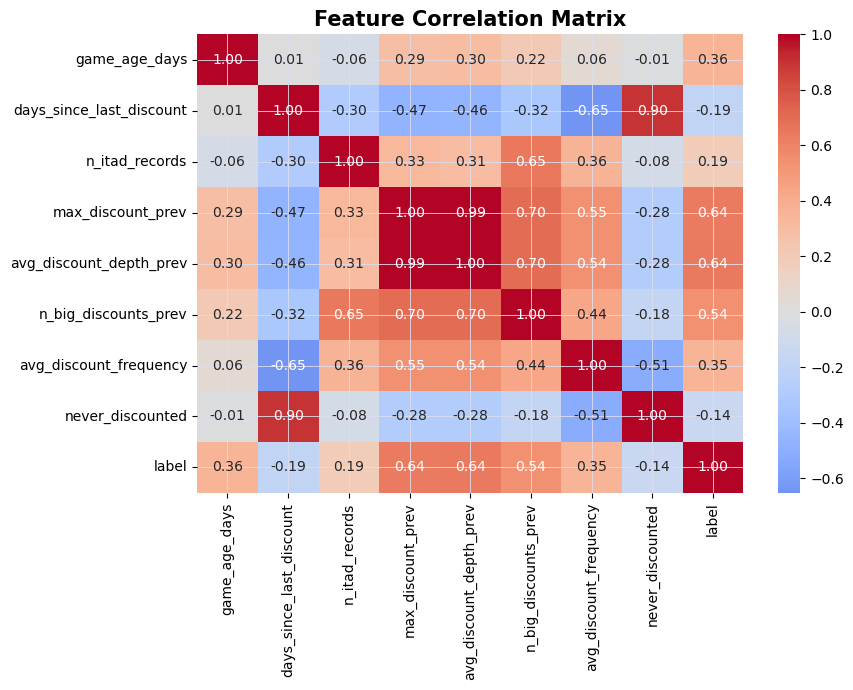

In [124]:
# ── Correlation Heatmap ──────────────────────────────────────────

import seaborn as sns
import matplotlib.pyplot as plt

feature_cols = [
    'game_age_days',
    'days_since_last_discount',
    'n_itad_records',
    'max_discount_prev',
    'avg_discount_depth_prev',
    'n_big_discounts_prev',
    'avg_discount_frequency',
    'never_discounted'
]

corr_df = df[feature_cols + ['label']]

corr_matrix = corr_df.corr()

plt.figure(figsize=(9,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [128]:
# ── McNemar Test ────────────────────────────────

from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

# RF ve GB tahminlerini al
y_pred_rf = trained["Random Forest"].predict(X_test_sc)
y_pred_gb = trained["Gradient Boosting"].predict(X_test_sc)

# McNemar tablosu: her ikisinin de doğru/yanlış olduğu durumlar
rf_correct = (y_pred_rf == y_test)
gb_correct = (y_pred_gb == y_test)

# 2x2 contingency table
b = np.sum(rf_correct & ~gb_correct)   # RF doğru, GB yanlış
c = np.sum(~rf_correct & gb_correct)   # RF yanlış, GB doğru

table = [[0, b], [c, 0]]  # McNemar sadece b ve c'ye bakar
result = mcnemar(table, exact=False, correction=True)

print(f"McNemar test: RF vs Gradient Boosting")
print(f"  b (RF correct, GB wrong) : {b}")
print(f"  c (RF wrong, GB correct) : {c}")
print(f"  chi2 statistic           : {result.statistic:.4f}")
print(f"  p-value                  : {result.pvalue:.4f}")
print(f"  Significant (p<0.05)?    : {result.pvalue < 0.05}")

McNemar test: RF vs Gradient Boosting
  b (RF correct, GB wrong) : 39
  c (RF wrong, GB correct) : 11
  chi2 statistic           : 14.5800
  p-value                  : 0.0001
  Significant (p<0.05)?    : True
